<a href="https://colab.research.google.com/github/aligreo/TriEncoder-Unet-Project/blob/main/msseg_preprocessing_archeticture_final_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!uv pip install SimpleITK monai gdown

Using Python 3.13.15 environment at: /usr
Resolved 42 packages in 478ms
Prepared 2 packages in 1.12s
Installed 2 packages in 8ms
 + monai==1.6.0
 + simpleitk==2.5.6


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
import os
import glob
import zipfile
import random
from pathlib import Path
import torch
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning, message=".*non-tuple sequence for multidimensional indexing.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*cuda.cudart module is deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*monai.transforms.*")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Load MSSEG dataset

In [4]:
MSSEG_TRAIN_ZIP = "/content/drive/MyDrive/MSSEG-Training.zip"
MSSEG_TEST_ZIP = "/content/drive/MyDrive/MSSEG-Testing.zip"
MSSEG_EXTRACT_DIR = "MSSEG-Training"
MSSEG_EXTRACT_DIR_TEST = "MSSEG-Testing"

def unzip_if_needed(zip_path, extract_dir):
    if zip_path and os.path.exists(zip_path):
        marker = Path(extract_dir) / ".extracted"
        if not marker.exists():
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)
            marker.touch()
        return extract_dir
    return extract_dir

def first_match(files, include_terms, exclude_terms=(), path_must_include=None):
    include_terms = [t.upper() for t in include_terms]
    exclude_terms = [t.upper() for t in exclude_terms]
    candidates = []
    for f in files:
        name = os.path.basename(f).upper()
        full_path_upper = f.upper()
        if path_must_include and path_must_include.upper() not in full_path_upper:
            continue
        if all(t in name for t in include_terms) and not any(t in name for t in exclude_terms):
            candidates.append(f)
    return sorted(candidates)[0] if candidates else None

def find_case_files(nii_files, case_log_id="Unknown Case"):
    if not nii_files:
        print(f"  [Warning] No NIfTI files found at all for {case_log_id}")
        return None

    flair = first_match(nii_files, ["FLAIR"], path_must_include="PREPROCESSED_DATA")
    t2 = first_match(nii_files, ["T2"], exclude_terms=["T2STAR", "T2_STAR"], path_must_include="PREPROCESSED_DATA")

    t1_exclude = ["GADO", "GD", "GAD", "CONTRAST", "FLAIR", "T2", "CONSENSUS", "MASK", "SEG", "GT"]
    t1 = first_match(nii_files, ["T1"], t1_exclude, path_must_include="PREPROCESSED_DATA")

    if not t1:
        dp_fallback = first_match(nii_files, ["DP"], t1_exclude, path_must_include="PREPROCESSED_DATA")
        if dp_fallback:
            print(f"  [CRITICAL WARNING] T1 is missing for {case_log_id}, and DP scan was found. Skipping case to avoid Channel Corruption!")

    label = (first_match(nii_files, ["CONSENSUS"]) or first_match(nii_files, ["LESION"]) or first_match(nii_files, ["GT"]))

    if not (flair and t1 and t2 and label):
        missing = []
        if not flair: missing.append("FLAIR")
        if not t1: missing.append("T1")
        if not t2: missing.append("T2")
        if not label: missing.append("LABEL/CONSENSUS")
        print(f"  [Dropped Case] {case_log_id} is missing modalities: {missing}")
        return None

    return {"flair": flair, "t1": t1, "t2": t2, "label": label}

def collect_dataset(root_dir, source_name):
    root_dir = str(root_dir)
    if not os.path.exists(root_dir): return []
    patient_map = {}

    for root, dirs, files in os.walk(root_dir):
        nii_in_dir = [os.path.join(root, f) for f in files if f.lower().endswith(('.nii', '.nii.gz'))]
        if not nii_in_dir: continue

        parts = Path(root).parts
        patient_folder = next((p for p in parts if "PATIENT_" in p.upper()), None)

        if patient_folder:
            idx = parts.index(patient_folder)
            center_folder = parts[idx-1] if idx > 0 else "Center_Unknown"
            key = f"{center_folder}_{patient_folder}"
            if key not in patient_map: patient_map[key] = []
            patient_map[key].extend(nii_in_dir)

    final_cases = []
    for key, all_files in patient_map.items():
        case_log_id = f"{source_name}_{key}"
        item = find_case_files(all_files, case_log_id=case_log_id)
        if item:
            item["source"] = source_name
            item["case_id"] = case_log_id
            final_cases.append(item)

    return sorted(final_cases, key=lambda x: x['case_id'])

msseg_root = unzip_if_needed(MSSEG_TRAIN_ZIP, MSSEG_EXTRACT_DIR)
msseg_test_root = unzip_if_needed(MSSEG_TEST_ZIP, MSSEG_EXTRACT_DIR_TEST)

msseg_train_files = collect_dataset(msseg_root, "MSSEG_TRAIN")
msseg_test_files = collect_dataset(msseg_test_root, "MSSEG_TEST")

print(f"MSSEG train cases found: {len(msseg_train_files)}")
print(f"MSSEG test cases found: {len(msseg_test_files)}")

MSSEG train cases found: 15
MSSEG test cases found: 38


## Data Preprocessing & SplitSplit

In [18]:
from sklearn.model_selection import train_test_split
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, ConcatItemsd, DeleteItemsd,
    RandCropByPosNegLabeld, EnsureTyped, CropForegroundd,
    RandFlipd, RandRotate90d, RandScaleIntensityd, RandShiftIntensityd,
    RandGaussianNoised, RandBiasFieldd, RandAdjustContrastd, Lambdad,
)
from monai.data import PersistentDataset, DataLoader
import os

def binarize_label(x):
    return (x > 0).astype(x.dtype)

base_transforms = [
    LoadImaged(keys=["flair", "t1", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
    Orientationd(keys=["flair", "t1", "t2", "label"], axcodes="RAS"),
    Spacingd(
        keys=["flair", "t1", "t2", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "bilinear", "bilinear", "nearest"),
        padding_mode="zeros",
    ),
    Lambdad(keys="label", func=binarize_label),
    CropForegroundd(keys=["flair", "t1", "t2", "label"], source_key="flair"),
    NormalizeIntensityd(keys=["flair", "t1", "t2"], nonzero=True, channel_wise=True),
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
    DeleteItemsd(keys=["flair", "t1", "t2"]),
]

num_samples_per_image = 6
train_transforms = Compose(base_transforms + [
    RandCropByPosNegLabeld(
        keys=["image", "label"], label_key="label",
        spatial_size=(96, 96, 96), pos=5, neg=1,
        num_samples=num_samples_per_image, image_key="image", image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.25, max_k=3),
    RandScaleIntensityd(keys="image", factors=0.2, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.15, prob=0.5),
    RandGaussianNoised(keys="image", prob=0.15, mean=0.0, std=0.01),
    RandBiasFieldd(keys="image", prob=0.15, coeff_range=(0.0, 0.03)),
    RandAdjustContrastd(keys="image", prob=0.2, gamma=(0.8, 1.2)),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])
test_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])

# Randomly choose 12 Train and 3 Val from the 15 train files
shuffled_files = random.sample(msseg_train_files, len(msseg_train_files))
train_files = shuffled_files[:12]
val_files = shuffled_files[12:15]
test_files = msseg_test_files

print(f"--- Dataset Statistics ---")
print(f"Initial volumes for Train: {len(train_files)}")
print(f"Initial volumes for Val: {len(val_files)}")
print(f"Initial volumes for Test: {len(test_files)}")

cache_dir_train = "/content/persistent_cache_train"
cache_dir_val = "/content/persistent_cache_val"
cache_dir_test = "/content/persistent_cache_test"

os.makedirs(cache_dir_train, exist_ok=True)
os.makedirs(cache_dir_val, exist_ok=True)
os.makedirs(cache_dir_test, exist_ok=True)

train_ds = PersistentDataset(data=train_files, transform=train_transforms, cache_dir=cache_dir_train)
val_ds = PersistentDataset(data=val_files, transform=val_transforms, cache_dir=cache_dir_val)
test_ds = PersistentDataset(data=test_files, transform=test_transforms, cache_dir=cache_dir_test)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

--- Dataset Statistics ---
Initial volumes for Train: 12
Initial volumes for Val: 3
Initial volumes for Test: 38


## Data Analysis

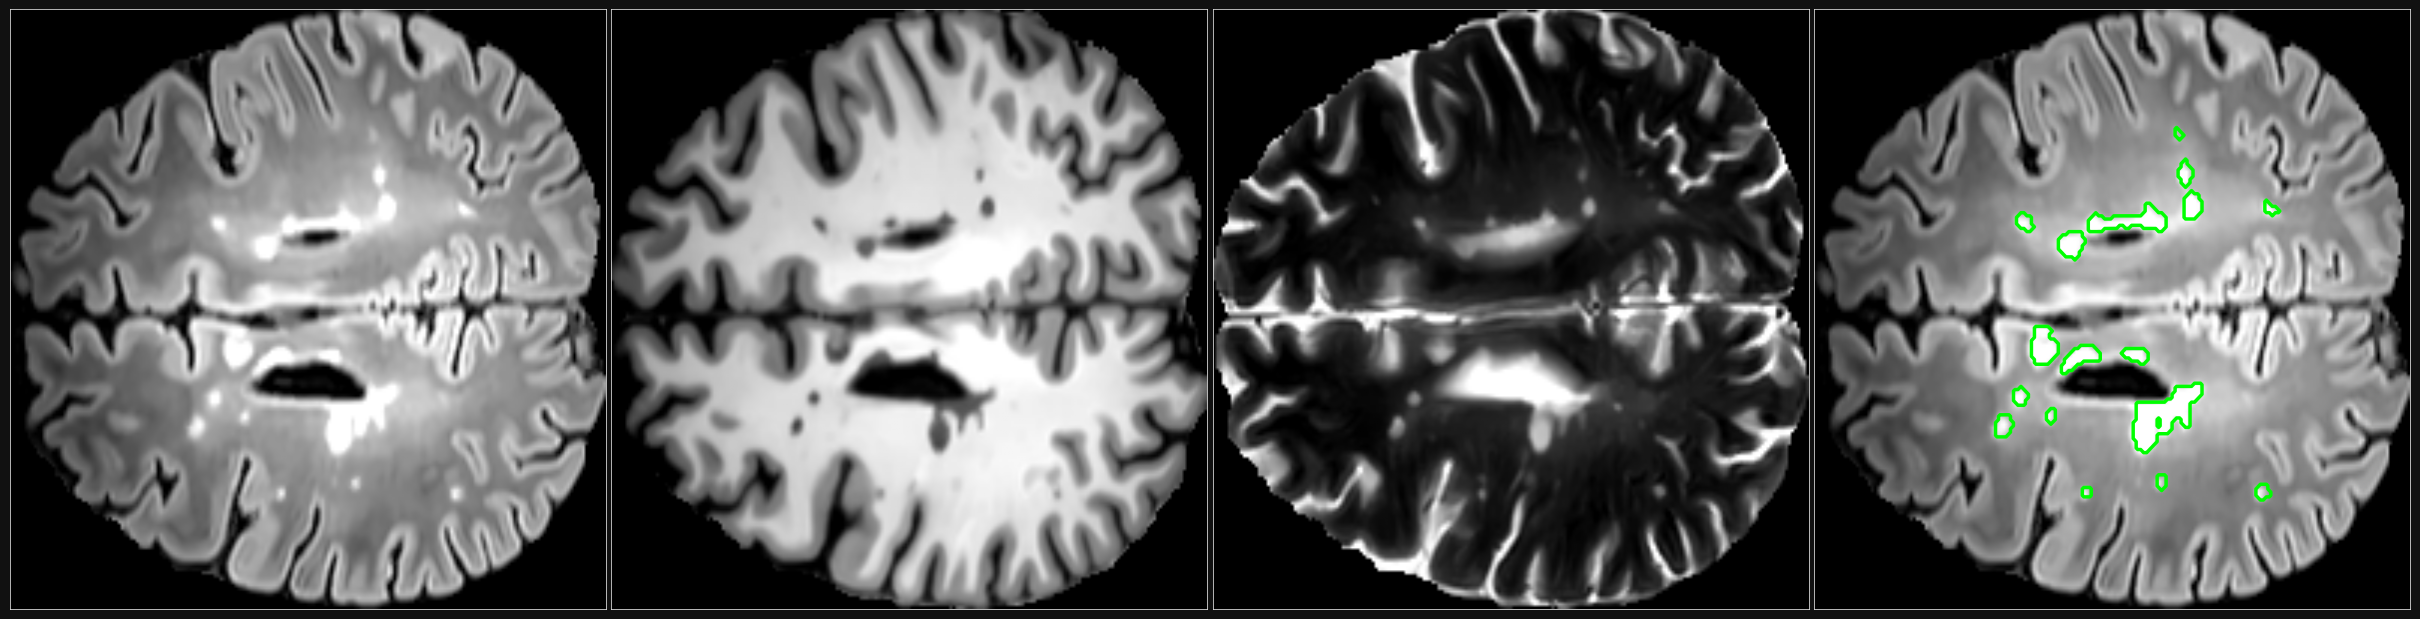

In [6]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

def normalize_image(img):
    img = img.astype(np.float32)
    mask = img > 0
    if np.any(mask):
        low = np.percentile(img[mask], 2)
        high = np.percentile(img[mask], 98)
        img = np.clip(img, low, high)
        img = (img - low) / (high - low + 1e-8)
    return img

def crop_brain(img, margin=0):
    mask = img > 0
    if not np.any(mask): return img, (0, img.shape[0], 0, img.shape[1])
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    y0, x0 = max(y0 - margin, 0), max(x0 - margin, 0)
    y1, x1 = min(y1 + margin, img.shape[0]), min(x1 + margin, img.shape[1])
    return img[y0:y1, x0:x1], (y0, y1, x0, x1)

def visualize_sample(sample_dict, slice_idx=None):
    data = {k: nib.load(sample_dict[k]).get_fdata() for k in ["flair", "t1", "t2", "label"]}
    if slice_idx is None:
        lesion_area = data["label"].sum(axis=(0, 1))
        slice_idx = np.argmax(lesion_area) if lesion_area.max() > 0 else data["label"].shape[2] // 2

    slices = {k: data[k][:, :, slice_idx] for k in data}
    for k in ["flair", "t1", "t2"]: slices[k] = normalize_image(slices[k])
    _, bbox = crop_brain(slices["flair"])
    y0, y1, x0, x1 = bbox
    for k in slices: slices[k] = slices[k][y0:y1, x0:x1]

    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=100, facecolor='#111111')

    panels = [
        (slices["flair"], "gray", None),
        (slices["t1"], "gray", None),
        (slices["t2"], "gray", None),
        (slices["flair"], "gray", slices["label"])
    ]

    for i, (img, cmap, lbl) in enumerate(panels):
        ax = axes[i]
        ax.imshow(img, cmap=cmap, aspect='auto', interpolation='bilinear', origin='lower')

        if lbl is not None:
            ax.contour(lbl, levels=[0.5], colors='lime', linewidths=2.5, origin='lower')

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('white')
            spine.set_linewidth(0.5)

        ax.set_xticks([])
        ax.set_yticks([])

    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0.01)
    plt.show()

if 'train_files' in globals() and train_files:
    visualize_sample(train_files[0])

## Model Architecture (Tri-Encoder with Deep Supervision)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class ConvBlock3D(nn.Module):
    def __init__(self, input_channels, output_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv3d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout3d(p=dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class AttentionGate3D(nn.Module):
    def __init__(self, gating_channels, skip_channels, intermediate_channels):
        super().__init__()
        self.W_gating = nn.Sequential(
            nn.Conv3d(gating_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.W_skip = nn.Sequential(
            nn.Conv3d(skip_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.attention_filter = nn.Sequential(
            nn.Conv3d(intermediate_channels, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.relu = nn.LeakyReLU(0.01, inplace=True)

    def forward(self, gating_signal, skip_connection):
        relevance_map = self.relu(self.W_gating(gating_signal) + self.W_skip(skip_connection))
        attention_coefficients = self.attention_filter(relevance_map)
        gated_skip = skip_connection * attention_coefficients
        return gated_skip, attention_coefficients


class ModalityGate3D(nn.Module):
    def __init__(self, num_modalities, channels_per_modality, reduction=4):
        super().__init__()
        total_channels = num_modalities * channels_per_modality
        self.num_modalities = num_modalities
        self.pool = nn.AdaptiveAvgPool3d(1)
        hidden = max(total_channels // reduction, num_modalities)
        self.mlp = nn.Sequential(
            nn.Linear(total_channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_modalities),
        )
        self.softmax = nn.Softmax(dim=1)

    def forward(self, modality_features):
        b = modality_features[0].shape[0]
        stacked = torch.cat(modality_features, dim=1)
        pooled = self.pool(stacked).view(b, -1)
        weights = self.softmax(self.mlp(pooled))
        gated = []
        for i, feat in enumerate(modality_features):
            w = weights[:, i].view(b, 1, 1, 1, 1)
            gated.append(feat * w)
        return gated, weights


class TriEncoderAttentionUNet3D(nn.Module):
    def __init__(self, dropout=0.25, modality_dropout_p=0.15, flair_only_ablation=True):
        super().__init__()
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)
        self.modality_dropout_p = modality_dropout_p
        self.flair_only_ablation = flair_only_ablation

        self.flair_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t1_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t2_l1 = ConvBlock3D(1, 16, dropout=0.0)

        self.flair_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t1_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t2_level_2 = ConvBlock3D(16, 32, dropout=dropout)

        self.modality_gate_l1 = ModalityGate3D(num_modalities=3, channels_per_modality=16)
        self.modality_gate_l2 = ModalityGate3D(num_modalities=3, channels_per_modality=32)

        self.fuse_l1 = ConvBlock3D(48, 32, dropout=dropout)
        self.fuse_level_2 = ConvBlock3D(96, 64, dropout=dropout)
        self.joint_l3 = ConvBlock3D(64, 128, dropout=dropout)

        self.bottleneck = ConvBlock3D(128, 256, dropout=dropout * 2)

        self.up3 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionGate3D(128, 128, 64)
        self.dec3 = ConvBlock3D(256, 128, dropout=dropout)

        self.up2 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionGate3D(64, 64, 32)
        self.dec2 = ConvBlock3D(128, 64, dropout=dropout)

        self.up1 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.att1 = AttentionGate3D(32, 32, 16)
        self.dec1 = ConvBlock3D(64, 32, dropout=dropout)

        self.final = nn.Conv3d(32, 1, kernel_size=1)
        self.aux3 = nn.Conv3d(128, 1, kernel_size=1)
        self.aux2 = nn.Conv3d(64, 1, kernel_size=1)

    def _apply_modality_dropout(self, flair, t1, t2):
        if not self.training or self.modality_dropout_p <= 0:
            return flair, t1, t2
        b = flair.shape[0]
        drop_mask = torch.rand(b, 3, device=flair.device) < self.modality_dropout_p
        all_dropped = drop_mask.all(dim=1)
        if all_dropped.any():
            keep_idx = torch.randint(0, 3, (int(all_dropped.sum()),), device=flair.device)
            drop_mask[all_dropped, keep_idx] = False
        keep_flair = (~drop_mask[:, 0]).float().view(b, 1, 1, 1, 1)
        keep_t1 = (~drop_mask[:, 1]).float().view(b, 1, 1, 1, 1)
        keep_t2 = (~drop_mask[:, 2]).float().view(b, 1, 1, 1, 1)
        return flair * keep_flair, t1 * keep_t1, t2 * keep_t2

    def forward(self, x, return_aux=True, return_attention=False):
        flair_input = x[:, 0:1]
        t1_input = x[:, 1:2]
        t2_input = x[:, 2:3]

        # ABLATION: Completely exclude T1 and T2
        if self.flair_only_ablation:
            t1_input = torch.zeros_like(t1_input)
            t2_input = torch.zeros_like(t2_input)

        flair_input, t1_input, t2_input = self._apply_modality_dropout(flair_input, t1_input, t2_input)

        f1 = self.flair_l1(flair_input)
        t1_1 = self.t1_l1(t1_input)
        t2_1 = self.t2_l1(t2_input)
        [f1_g, t1_1_g, t2_1_g], modality_weights_l1 = self.modality_gate_l1([f1, t1_1, t2_1])
        fused_skip_l1 = self.fuse_l1(torch.cat([f1_g, t1_1_g, t2_1_g], dim=1))

        f2 = self.flair_level_2(self.pool(f1))
        t1_2 = self.t1_level_2(self.pool(t1_1))
        t2_2 = self.t2_level_2(self.pool(t2_1))
        [f2_g, t1_2_g, t2_2_g], modality_weights_l2 = self.modality_gate_l2([f2, t1_2, t2_2])
        fused_skip_l2 = self.fuse_level_2(torch.cat([f2_g, t1_2_g, t2_2_g], dim=1))

        fused_f3 = self.joint_l3(self.pool(fused_skip_l2))
        bottle = self.bottleneck(self.pool(fused_f3))

        up_l3 = self.up3(bottle)
        att3_out, att3_map = self.att3(up_l3, fused_f3)
        dec_l3 = self.dec3(torch.cat([up_l3, att3_out], dim=1))

        up_l2 = self.up2(dec_l3)
        att2_out, att2_map = self.att2(up_l2, fused_skip_l2)
        dec_l2 = self.dec2(torch.cat([up_l2, att2_out], dim=1))

        up_l1 = self.up1(dec_l2)
        att1_out, att1_map = self.att1(up_l1, fused_skip_l1)
        dec_l1 = self.dec1(torch.cat([up_l1, att1_out], dim=1))

        out_final = self.final(dec_l1)

        o3 = o2 = None
        if return_aux:
            o3 = F.interpolate(self.aux3(dec_l3), size=out_final.shape[2:], mode="trilinear", align_corners=False)
            o2 = F.interpolate(self.aux2(dec_l2), size=out_final.shape[2:], mode="trilinear", align_corners=False)

        if return_attention:
            return (out_final, o3, o2, {"att1": att1_map, "att2": att2_map, "att3": att3_map}, {"level1": modality_weights_l1, "level2": modality_weights_l2}) if return_aux else (out_final, {"att1": att1_map, "att2": att2_map, "att3": att3_map}, {"level1": modality_weights_l1, "level2": modality_weights_l2})

        return (out_final, o3, o2) if return_aux else out_final

model = TriEncoderAttentionUNet3D(dropout=0.10, flair_only_ablation=True).to(device)

## Loss function

In [8]:
from monai.losses import DiceFocalLoss

class DeepSupervisedDiceFocalLoss(nn.Module):
    def __init__(self, lambda_dice=0.7, lambda_focal=0.3):
        super().__init__()
        self.base_loss = DiceFocalLoss(
            sigmoid=True,
            squared_pred=True,
            lambda_dice=lambda_dice,
            lambda_focal=lambda_focal
        )
        self.aux_weights = [1.0, 0.3, 0.15]

    def forward(self, logits_list, targets):
        loss = 0.0
        for i, logits in enumerate(logits_list):
            w = self.aux_weights[i]
            if logits.shape[2:] != targets.shape[2:]:
                logits = F.interpolate(logits, size=targets.shape[2:], mode="trilinear", align_corners=False)
            loss += w * self.base_loss(logits, targets)
        normalizer = sum(self.aux_weights[:len(logits_list)])
        return loss / normalizer

criterion = DeepSupervisedDiceFocalLoss(lambda_dice=0.7, lambda_focal=0.3)

## Training Loop

In [9]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import math
import csv

# --- T4-specific setup ---
torch.backends.cudnn.benchmark = True
AMP_DTYPE = torch.float16

max_epochs = 150
roi_size = (96, 96, 96)
sw_batch_size = 2
accumulation_steps = 2
weight_path = "best_tri_encoder_msseg_only_flair_only.pth"
VAL_EVERY = 2
VAL_OVERLAP = 0.25
LOG_EVERY = 10
log_csv_path = "training_metrics_log_flair_only.csv"

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

steps_per_epoch = math.ceil(len(train_loader) / accumulation_steps)
total_steps = steps_per_epoch * max_epochs
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4, total_steps=total_steps, pct_start=0.3)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred = AsDiscrete(threshold=0.5)

history_train_loss = []
history_train_acc = []
history_val_loss = []
history_val_dice = []
history_val_acc = []
best_metric = -1
scheduler_steps_taken = 0

if os.path.exists(weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"Loaded existing weights from {weight_path}; continuing training.")

if not os.path.exists(log_csv_path):
    with open(log_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_dice", "val_acc", "lr"])


def predict_fn(inputs, overlap=0.5):
    return sliding_window_inference(
        inputs=inputs, roi_size=roi_size, sw_batch_size=sw_batch_size,
        predictor=lambda x: model(x, return_aux=False), overlap=overlap, mode="gaussian",
    )


def run_validation(overlap=VAL_OVERLAP):
    model.eval()
    dice_metric.reset()
    val_loss_total = 0.0
    correct_voxels = 0
    total_voxels = 0

    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device, non_blocking=True)
            val_labels = val_data["label"].to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
                val_logits = predict_fn(val_inputs, overlap=overlap)
                val_loss_total += criterion((val_logits,), val_labels).item()
            val_probs = torch.sigmoid(val_logits)
            val_outputs_discrete = [post_pred(i) for i in val_probs]
            dice_metric(y_pred=val_outputs_discrete, y=val_labels)

            preds_stacked = torch.stack(val_outputs_discrete)
            correct_voxels += (preds_stacked == val_labels).sum().item()
            total_voxels += val_labels.numel()

    avg_dice = dice_metric.aggregate().item()
    avg_val_loss = val_loss_total / max(len(val_loader), 1)
    avg_val_acc = correct_voxels / max(total_voxels, 1)
    dice_metric.reset()
    return avg_val_loss, avg_dice, avg_val_acc


def log_to_csv(epoch, train_loss, train_acc, val_loss, val_dice, val_acc, lr):
    with open(log_csv_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, f"{train_loss:.6f}", f"{train_acc:.6f}", f"{val_loss:.6f}",
                          f"{val_dice:.6f}", f"{val_acc:.6f}", f"{lr:.8e}"])


for epoch in range(max_epochs):
    model.train()
    epoch_loss = torch.zeros(1, device=device)
    correct_voxels_train = 0
    total_voxels_train = 0
    optimizer.zero_grad(set_to_none=True)

    for step, batch_data in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False)):
        inputs = batch_data["image"].to(device, non_blocking=True)
        labels = batch_data["label"].to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
            logits_final, logits_aux3, logits_aux2 = model(inputs, return_aux=True)
            loss = criterion((logits_final, logits_aux3, logits_aux2), labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=12.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            if scheduler_steps_taken < total_steps:
                scheduler.step()
                scheduler_steps_taken += 1

        epoch_loss += loss.detach() * accumulation_steps

        # voxel-wise train accuracy, computed from the already-available logits (no extra forward pass)
        with torch.no_grad():
            train_preds = (torch.sigmoid(logits_final.detach()) > 0.5).float()
            correct_voxels_train += (train_preds == labels).sum().item()
            total_voxels_train += labels.numel()

    epoch_loss = (epoch_loss / max(step + 1, 1)).item()
    epoch_train_acc = correct_voxels_train / max(total_voxels_train, 1)
    history_train_loss.append(epoch_loss)
    history_train_acc.append(epoch_train_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    is_log_epoch = ((epoch + 1) % LOG_EVERY == 0) or (epoch + 1) == max_epochs
    run_val = ((epoch + 1) % VAL_EVERY == 0) or epoch == 0 or (epoch + 1) == max_epochs or is_log_epoch

    if run_val:
        avg_val_loss, avg_val_dice, avg_val_acc = run_validation()
        history_val_loss.append(avg_val_loss)
        history_val_dice.append(avg_val_dice)
        history_val_acc.append(avg_val_acc)
        print(f"Epoch [{epoch+1}/{max_epochs}]  Train Loss: {epoch_loss:.4f}  Train Acc: {epoch_train_acc:.4f}  "
              f"Val Loss: {avg_val_loss:.4f}  Val Dice: {avg_val_dice:.4f}  "
              f"Val Acc: {avg_val_acc:.4f}  LR: {current_lr:.2e}")

        if avg_val_dice > best_metric:
            best_metric = avg_val_dice
            torch.save(model.state_dict(), weight_path)
            print(f"  *** New Best Val Dice ({best_metric:.4f}) at epoch {epoch+1} - Model Saved ***")

        if is_log_epoch:
            log_to_csv(epoch + 1, epoch_loss, epoch_train_acc, avg_val_loss, avg_val_dice, avg_val_acc, current_lr)
    else:
        print(f"Epoch [{epoch+1}/{max_epochs}]  Train Loss: {epoch_loss:.4f}  Train Acc: {epoch_train_acc:.4f}  LR: {current_lr:.2e}")

print(f"Training complete. Best Val Dice: {best_metric:.4f}")
print(f"Metrics logged to {log_csv_path}")

Epoch 1/150:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [1/150]  Train Loss: 0.6881  Train Acc: 0.9060  Val Loss: 0.7229  Val Dice: 0.0114  Val Acc: 0.9521  LR: 4.12e-06
  *** New Best Val Dice (0.0114) at epoch 1 - Model Saved ***


Epoch 2/150:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [2/150]  Train Loss: 0.6882  Train Acc: 0.9057  Val Loss: 0.7224  Val Dice: 0.0127  Val Acc: 0.9520  LR: 4.47e-06
  *** New Best Val Dice (0.0127) at epoch 2 - Model Saved ***


Epoch 3/150:   0%|          | 0/12 [00:00<?, ?it/s]

...

Epoch [148/150]  Train Loss: 0.4185  Train Acc: 0.9871  Val Loss: 0.6350  Val Dice: 0.5446  Val Acc: 0.9981  LR: 7.56e-08


Epoch 149/150:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [149/150]  Train Loss: 0.4336  Train Acc: 0.9848  LR: 1.59e-08


Epoch 150/150:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [150/150]  Train Loss: 0.3978  Train Acc: 0.9895  Val Loss: 0.6350  Val Dice: 0.5446  Val Acc: 0.9981  LR: 1.02e-09
Training complete. Best Val Dice: 0.5700
Metrics logged to training_metrics_log_flair_only.csv


## Final Test Evaluation

In [10]:
weight_path = "/content/best_tri_encoder_msseg_only_flair_only.pth"
model.load_state_dict(torch.load(weight_path, map_location=device))

<All keys matched successfully>

In [11]:
import os
import time
import glob
import torch
import numpy as np
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm

cache_dir = "eval_cache"
os.makedirs(cache_dir, exist_ok=True)

post_pred = AsDiscrete(threshold=0.5)
roi_size = (96, 96, 96)
sw_batch_size = 2

model.eval()
case_id_to_file = {}
total_inf_time = 0.0

print("Running inference once on the test set and caching results...")
with torch.no_grad():
    for i, test_data in enumerate(tqdm(test_loader, desc="Caching Predictions")):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device)
        case_id = test_data.get("case_id", [f"Case_{i}"])[0]

        start_time = time.time()
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = sliding_window_inference(
                inputs, roi_size, sw_batch_size,
                lambda x: model(x, return_aux=False), overlap=0.5, mode="gaussian"
            )
        inf_time = time.time() - start_time
        total_inf_time += inf_time

        probs = torch.sigmoid(logits).cpu()
        preds = post_pred(probs).cpu()

        save_path = os.path.join(cache_dir, f"case_{i:03d}.pt")
        torch.save({
            "case_id": case_id,
            "probs": probs,
            "preds": preds,
            "labels": labels.cpu(),
            "flair": inputs[0, 0].cpu(),
            "image_meta": test_data.get("image_meta_dict", {}),
            "label_meta": test_data.get("label_meta_dict", {}),
            "inf_time": inf_time,
        }, save_path)
        case_id_to_file[case_id] = save_path

cache_files = sorted(glob.glob(os.path.join(cache_dir, "case_*.pt")))
print(f"Cached {len(cache_files)} cases in '{cache_dir}/'. Total inference time: {total_inf_time:.2f}s")

Running inference once on the test set and caching results...


Caching Predictions:   0%|          | 0/38 [00:00<?, ?it/s]

Cached 38 cases in 'eval_cache/'. Total inference time: 21.29s


## evaluation for each case

In [12]:
import os
import glob
import pandas as pd
import torch
import numpy as np
import warnings
from tqdm.auto import tqdm
from monai.metrics import DiceMetric, ConfusionMatrixMetric, HausdorffDistanceMetric, get_confusion_matrix

# Hide specific warnings
warnings.filterwarnings("ignore", message=".*always_return_as_numpy.*")
warnings.filterwarnings("ignore", message=".*the ground truth of class 0 is all 0.*")

# Metrics for individual case calculation - Using reduction='none' and computing on CPU for stability
dice_metric = DiceMetric(include_background=False, reduction="none")
conf_metric = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall", "accuracy"], reduction="none")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="none")

results = []

with torch.no_grad():
    for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Per-case Metrics"):
        cached = torch.load(cache_path, map_location="cpu", weights_only=False)
        test_outputs_discrete = cached["preds"]
        test_labels_cpu = cached["labels"]
        case_id = cached["case_id"]
        inf_time = cached["inf_time"]

        # Per-case Metrics calculation
        dice_metric(y_pred=test_outputs_discrete, y=test_labels_cpu)
        conf_metric(y_pred=test_outputs_discrete, y=test_labels_cpu)
        hd95_metric(y_pred=test_outputs_discrete, y=test_labels_cpu)

        # Get Confusion Matrix Raw Values (TP, FP, TN, FN)
        conf_m = get_confusion_matrix(y_pred=test_outputs_discrete, y=test_labels_cpu)
        tp = conf_m[..., 0].item()
        fp = conf_m[..., 1].item()
        tn = conf_m[..., 2].item()
        fn = conf_m[..., 3].item()

        # Aggregate and Extract (each metric contains only 1 case because we reset below)
        dice_val = dice_metric.aggregate().item()
        c_res = conf_metric.aggregate()
        prec = c_res[0].item()
        sens = c_res[1].item()
        acc = c_res[2].item()
        hd95_val = hd95_metric.aggregate().item()

        gt_vol = torch.sum(test_labels_cpu).item()

        results.append({
            "Case ID": case_id,
            "Dice": round(dice_val, 4),
            "Accuracy": round(acc, 6),
            "Precision": round(prec, 4),
            "Sensitivity": round(sens, 4),
            "HD95 (mm)": round(hd95_val, 3),
            "TP": int(tp),
            "FP": int(fp),
            "TN": int(tn),
            "FN": int(fn),
            "Lesion Vol (vx)": int(gt_vol),
            "Inf Time (s)": round(inf_time, 2)
        })

        # IMPORTANT: Reset metrics for the next iteration
        dice_metric.reset()
        conf_metric.reset()
        hd95_metric.reset()

# Display Table
df_final_results = pd.DataFrame(results)
display(df_final_results)

print(f"\n--- AGGREGATE SUMMARY ---")
print(f"Mean Dice: {df_final_results['Dice'].mean():.4f}")
print(f"Mean HD95: {df_final_results['HD95 (mm)'].mean():.3f} mm")

Per-case Metrics:   0%|          | 0/38 [00:00<?, ?it/s]

,Case ID,Dice,Accuracy,Precision,Sensitivity,HD95 (mm),TP,FP,TN,FN,Lesion Vol (vx),Inf Time (s)
0,MSSEG_TEST_Center_01_Patient_01,0.0732,0.997747,0.0384,0.7725,57.053,275,6880,3082684,81,356,0.47
1,MSSEG_TEST_Center_01_Patient_02,0.8049,0.996785,0.7565,0.8598,3.162,21030,6768,3140566,3428,24458,0.42
2,MSSEG_TEST_Center_01_Patient_03,0.7422,0.998116,0.6643,0.8407,13.601,9232,4665,3388804,1749,10981,0.42
3,MSSEG_TEST_Center_01_Patient_04,0.8305,0.996268,0.7626,0.9116,1.414,31752,9884,3428896,3078,34830,0.88
4,MSSEG_TEST_Center_01_Patient_05,0.7435,0.997694,0.7262,0.7616,9.000,11990,4521,3567326,3753,15743,0.94
5,MSSEG_TEST_Center_01_Patient_06,0.6703,0.994021,0.7120,0.6333,11.533,19168,7755,3115129,11098,30266,0.42
6,MSSEG_TEST_Center_01_Patient_07,0.5336,0.998316,0.4198,0.7323,25.110,3367,4654,3484728,1231,4598,0.49
7,MSSEG_TEST_Center_01_Patient_08,0.7724,0.996599,0.7986,0.7478,8.541,16019,4039,2750300,5402,21421,0.42
8,MSSEG_TEST_Center_01_Patient_09,0.1666,0.998492,0.0942,0.7202,47.634,435,4183,2882053,169,604,0.49
9,MSSEG_TEST_Center_01_Patient_10,0.6214,0.998314,0.4929,0.8405,17.029,4342,4467,3128709,824,5166,0.43



--- AGGREGATE SUMMARY ---
Mean Dice: 0.5512
Mean HD95: 24.315 mm


## Average results on test dataset

In [13]:
import pandas as pd

# Update column names to English
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Define the columns for which to calculate summary statistics
columns_to_summarize = ['Dice', 'Accuracy', 'Precision', 'Sensitivity', 'HD95 (mm)']

# Calculate mean and standard deviation for the selected columns
summary_stats = df_final_results[columns_to_summarize].agg(['mean', 'std']).T
summary_stats.columns = ['Mean', 'Std'] # Rename columns as requested

display(summary_stats)

,Mean,Std
Dice,0.5512,0.2532
Accuracy,0.9972,0.0014
Precision,0.4707,0.2852
Sensitivity,0.8141,0.1058
HD95 (mm),24.3151,21.1878


In [14]:
import os
import glob
import numpy as np
import pandas as pd
import torch
from scipy.ndimage import label
from tqdm.auto import tqdm

lesion_results = []

print("Computing Lesion-wise Evaluation from cache (38 cases)...")

for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Lesion Evaluation"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    labels = cached["labels"].numpy().squeeze()  # [D, H, W]
    preds = cached["preds"].numpy().squeeze()
    case_id = cached["case_id"]

    # 1. Connected Components for Lesions
    gt_labels, n_gt = label(labels)
    pred_labels, n_pred = label(preds)

    # 2. Match lesions
    # Lesion-wise TP (Sens side): How many GT lesions were hit by predictions?
    lw_tp_sens = 0
    for g in range(1, n_gt + 1):
        gt_mask = (gt_labels == g)
        if np.any(preds[gt_mask] > 0):
            lw_tp_sens += 1

    # Lesion-wise TP (Prec side): How many Pred lesions hit at least one GT?
    lw_tp_prec = 0
    for p in range(1, n_pred + 1):
        pred_mask = (pred_labels == p)
        if np.any(labels[pred_mask] > 0):
            lw_tp_prec += 1

    # 3. Calculate Derived Metrics
    lw_fn = n_gt - lw_tp_sens
    lw_fp = n_pred - lw_tp_prec

    precision = lw_tp_prec / n_pred if n_pred > 0 else (1.0 if n_gt == 0 else 0.0)
    sensitivity = lw_tp_sens / n_gt if n_gt > 0 else (1.0 if n_pred == 0 else 0.0)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0

    lesion_results.append({
        "Case ID": case_id,
        "GT Lesions": n_gt,
        "Pred Lesions": n_pred,
        "LW TP (Sens)": lw_tp_sens,
        "LW TP (Prec)": lw_tp_prec,
        "LW FP": lw_fp,
        "LW FN": lw_fn,
        "LW Precision": round(precision, 4),
        "LW Sensitivity": round(sensitivity, 4),
        "LW F1": round(f1, 4)
    })

# Create DataFrame
df_lesion_wise = pd.DataFrame(lesion_results)

# Display overall summary
print("\n--- LESION-WISE AGGREGATE SUMMARY ---")
summary_cols = ["LW Precision", "LW Sensitivity", "LW F1"]
display(df_lesion_wise[summary_cols].mean().to_frame("Mean Across 38 Cases"))

# Display full table
display(df_lesion_wise)

Computing Lesion-wise Evaluation from cache (38 cases)...


Lesion Evaluation:   0%|          | 0/38 [00:00<?, ?it/s]


--- LESION-WISE AGGREGATE SUMMARY ---


,Mean Across 38 Cases
LW Precision,0.4735
LW Sensitivity,0.5828
LW F1,0.4100


,Case ID,GT Lesions,Pred Lesions,LW TP (Sens),LW TP (Prec),LW FP,LW FN,LW Precision,LW Sensitivity,LW F1
0,MSSEG_TEST_Center_01_Patient_01,6,248,3,3,245,3,0.0121,0.5000,0.0236
1,MSSEG_TEST_Center_01_Patient_02,47,30,31,24,6,16,0.8000,0.6596,0.7230
2,MSSEG_TEST_Center_01_Patient_03,74,38,35,34,4,39,0.8947,0.4730,0.6188
3,MSSEG_TEST_Center_01_Patient_04,70,23,17,12,11,53,0.5217,0.2429,0.3314
4,MSSEG_TEST_Center_01_Patient_05,92,63,44,52,11,48,0.8254,0.4783,0.6056
5,MSSEG_TEST_Center_01_Patient_06,205,58,45,50,8,160,0.8621,0.2195,0.3499
6,MSSEG_TEST_Center_01_Patient_07,36,71,14,17,54,22,0.2394,0.3889,0.2964
7,MSSEG_TEST_Center_01_Patient_08,95,66,53,61,5,42,0.9242,0.5579,0.6958
8,MSSEG_TEST_Center_01_Patient_09,13,163,4,4,159,9,0.0245,0.3077,0.0455
9,MSSEG_TEST_Center_01_Patient_10,39,53,19,14,39,20,0.2642,0.4872,0.3426


## Result analysis based on lesion volume

In [15]:
import os
import glob
import numpy as np
import pandas as pd
import torch
from scipy.ndimage import label
from tqdm.auto import tqdm

# Define thresholds for lesion sizes in mm3
# Assuming 1x1x1 mm spacing from earlier transforms, so 1 voxel = 1 mm3
SMALL_LIMIT = 50
MEDIUM_LIMIT = 500

size_metrics = {
    "small": {"gt_count": 0, "tp_count": 0, "pred_count": 0},
    "medium": {"gt_count": 0, "tp_count": 0, "pred_count": 0},
    "large": {"gt_count": 0, "tp_count": 0, "pred_count": 0}
}

def get_size_category(volume):
    if volume < SMALL_LIMIT: return "small"
    if volume < MEDIUM_LIMIT: return "medium"
    return "large"

print("Analyzing lesion size distribution from cache...")
for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Analyzing by Size"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    labels = cached["labels"].numpy().squeeze()
    preds = cached["preds"].numpy().squeeze()

    gt_labels, n_gt = label(labels)
    pred_labels, n_pred = label(preds)

    # Analyze GT lesions
    for g in range(1, n_gt + 1):
        gt_mask = (gt_labels == g)
        vol = np.sum(gt_mask)
        cat = get_size_category(vol)
        size_metrics[cat]["gt_count"] += 1
        if np.any(preds[gt_mask] > 0):
            size_metrics[cat]["tp_count"] += 1

    # Analyze Pred lesions for Precision/F1
    for p in range(1, n_pred + 1):
        pred_mask = (pred_labels == p)
        vol = np.sum(pred_mask)
        cat = get_size_category(vol)
        size_metrics[cat]["pred_count"] += 1

# Finalizing calculations
summary_rows = []
for cat in ["small", "medium", "large"]:
    gt = size_metrics[cat]["gt_count"]
    tp = size_metrics[cat]["tp_count"]
    pred = size_metrics[cat]["pred_count"]

    missed = gt - tp
    sens = tp / gt if gt > 0 else 1.0
    prec = tp / pred if pred > 0 else 0.0
    f1 = 2 * (prec * sens) / (prec + sens) if (prec + sens) > 0 else 0.0

    summary_rows.append({
        "Lesion Size": cat,
        "Total GT": gt,
        "Detected (TP)": tp,
        "Missed (FN)": missed,
        "Sensitivity": round(sens, 4),
        "F1-Score": round(f1, 4)
    })

df_size_analysis = pd.DataFrame(summary_rows)
display(df_size_analysis)

Analyzing lesion size distribution from cache...


Analyzing by Size:   0%|          | 0/38 [00:00<?, ?it/s]

,Lesion Size,Total GT,Detected (TP),Missed (FN),Sensitivity,F1-Score
0,small,1243,317,926,0.2550,0.1642
1,medium,591,496,95,0.8393,0.8006
2,large,97,97,0,1.0000,0.7376


In [16]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import SaveImage
from tqdm.auto import tqdm

# Create output directory
output_dir = "msseg_predictions"
os.makedirs(output_dir, exist_ok=True)

# Initialize SaveImage transforms
# We disable resampling to keep original header info
save_prob = SaveImage(output_dir=output_dir, output_postfix="prob", output_ext=".nii.gz", resample=False, separate_folder=False)
save_bin = SaveImage(output_dir=output_dir, output_postfix="mask", output_ext=".nii.gz", resample=False, separate_folder=False)
save_gt = SaveImage(output_dir=output_dir, output_postfix="gt", output_ext=".nii.gz", resample=False, separate_folder=False)

print(f"Saving predictions for 38 cases to '{output_dir}'...")

for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Saving NIfTI & Overlays"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    probs = cached["probs"]
    binary_mask = cached["preds"]
    labels = cached["labels"]
    flair = cached["flair"]
    case_id = cached["case_id"]

    # 1. Save NIfTI files
    img_meta = cached.get("image_meta", {})
    label_meta = cached.get("label_meta", {})

    save_prob(probs[0], meta_data=img_meta)
    save_bin(binary_mask[0], meta_data=img_meta)
    save_gt(labels[0], meta_data=label_meta)

    # 2. Generate Overlay Visualization for the case
    gt_np = labels[0, 0].numpy()
    pred_np = binary_mask[0, 0].numpy()
    flair_np = flair.numpy()

    # Find slice with maximum ground truth lesion area
    slice_idx = np.argmax(np.sum(gt_np, axis=(0, 1)))

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(flair_np[:, :, slice_idx], cmap="gray", origin="lower")

    # Ground Truth in Lime Green
    if np.any(gt_np[:, :, slice_idx]):
        ax.contour(gt_np[:, :, slice_idx], levels=[0.5], colors="lime", linewidths=1.5)

    # Prediction in Dashed Red
    if np.any(pred_np[:, :, slice_idx]):
        ax.contour(pred_np[:, :, slice_idx], levels=[0.5], colors="red", linewidths=1.5, linestyles="dashed")

    ax.set_title(f"Overlay: {case_id} (Green=GT, Red=Pred)")
    ax.axis("off")

    plt.savefig(os.path.join(output_dir, f"{case_id}_overlay.png"), bbox_inches='tight')
    plt.close(fig)

print(f"\nAll files saved successfully in {output_dir}")

Saving predictions for 38 cases to 'msseg_predictions'...


Saving NIfTI & Overlays:   0%|          | 0/38 [00:00<?, ?it/s]

2026-08-27 14:46:10,850 INFO image_writer.py:197 - writing: msseg_predictions/0_prob.nii.gz
2026-08-27 14:46:11,533 INFO image_writer.py:197 - writing: msseg_predictions/0_mask.nii.gz
2026-08-27 14:46:11,661 INFO image_writer.py:197 - writing: msseg_predictions/0_gt.nii.gz
2026-08-27 14:46:12,040 INFO image_writer.py:197 - writing: msseg_predictions/1_prob.nii.gz
2026-08-27 14:46:12,771 INFO image_writer.py:197 - writing: msseg_predictions/1_mask.nii.gz
2026-08-27 14:46:12,910 INFO image_writer.py:197 - writing: msseg_predictions/1_gt.nii.gz
2026-08-27 14:46:13,302 INFO image_writer.py:197 - writing: msseg_predictions/2_prob.nii.gz
2026-08-27 14:46:14,032 INFO image_writer.py:197 - writing: msseg_predictions/2_mask.nii.gz
2026-08-27 14:46:14,174 INFO image_writer.py:197 - writing: msseg_predictions/2_gt.nii.gz
2026-08-27 14:46:14,536 INFO image_writer.py:197 - writing: msseg_predictions/3_prob.nii.gz
2026-08-27 14:46:15,387 INFO image_writer.py:197 - writing: msseg_predictions/3_mask.n

KeyboardInterrupt: 

## Save model output in NIfTI

In [ ]:
!zip -r /content/msseg_predictions.zip /content/msseg_predictions

  adding: content/msseg_predictions/ (stored 0%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_01_Patient_07_overlay.png (deflated 6%)
  adding: content/msseg_predictions/2_mask.nii.gz (deflated 77%)
  adding: content/msseg_predictions/35_gt.nii.gz (deflated 96%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_03_Patient_04_overlay.png (deflated 7%)
  adding: content/msseg_predictions/FLAIR_preprocessed_prob.nii.gz (deflated 0%)
  adding: content/msseg_predictions/29_gt.nii.gz (deflated 94%)
  adding: content/msseg_predictions/2_gt.nii.gz (deflated 71%)
  adding: content/msseg_predictions/13_gt.nii.gz (deflated 96%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_03_Patient_03_overlay.png (deflated 11%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_01_Patient_03_overlay.png (deflated 5%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_08_Patient_06_overlay.png (deflated 4%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_07_Patient_04_overlay.png

## interpretability results

In [19]:
import os
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 1. Identify representative cases
best_case_id = df_final_results.loc[df_final_results['Dice'].idxmax(), 'Case ID']
worst_case_id = df_final_results.loc[df_final_results['Dice'].idxmin(), 'Case ID']
avg_dice = df_final_results['Dice'].mean()
median_case_id = df_final_results.iloc[(df_final_results['Dice'] - avg_dice).abs().dropna().argsort()[:1]]['Case ID'].values[0]
small_lesion_case_id = df_lesion_wise.loc[df_lesion_wise['GT Lesions'].idxmax(), 'Case ID']

target_cases = {
    "Best": best_case_id,
    "Worst": worst_case_id,
    "Average": median_case_id,
    "Small_Lesions": small_lesion_case_id
}
target_ids = set(target_cases.values())

output_explain_dir = "interpretability_results"
os.makedirs(output_explain_dir, exist_ok=True)

model.eval()
print("Extracting interpretability outputs ONLY for representative cases...")

modality_weights_list = []
with torch.no_grad():
    for test_data in tqdm(test_loader, desc="Explainability Inference"):
        inputs = test_data["image"].to(device)
        case_id = test_data.get("case_id", ["Unknown"])[0]
        if case_id not in target_ids:
            continue

        # Central crop 96x96x96 forward (attention path only for the target case)
        d, h, w = inputs.shape[2:]
        crop_slice = inputs[:, :, d//2-48:d//2+48, h//2-48:h//2+48, w//2-48:w//2+48]

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            _, att_maps, weights = model(crop_slice, return_aux=False, return_attention=True)

        # Modality gate weights for this case
        mw1 = weights['level1'].cpu().numpy().mean(axis=0)
        mw2 = weights['level2'].cpu().numpy().mean(axis=0)
        modality_weights_list.append({
            "Case ID": case_id,
            "L1_FLAIR": mw1[0], "L1_T1": mw1[1], "L1_T2": mw1[2],
            "L2_FLAIR": mw2[0], "L2_T1": mw2[1], "L2_T2": mw2[2]
        })

        # Attention map visualization
        att_data = att_maps['att1'].cpu().numpy()[0, 0]
        mid = att_data.shape[2] // 2
        label_name = [k for k, v in target_cases.items() if v == case_id][0]

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(crop_slice[0, 0, :, :, mid].cpu().numpy(), cmap='gray')
        axes[0].set_title(f"Input - {label_name}")
        im = axes[1].imshow(att_data[:, :, mid], cmap='hot')
        axes[1].set_title("Attention Gate (L1)")
        plt.colorbar(im, ax=axes[1])
        plt.savefig(os.path.join(output_explain_dir, f"att_map_{label_name}.png"))
        plt.close(fig)

df_weights = pd.DataFrame(modality_weights_list)
df_weights.to_csv(os.path.join(output_explain_dir, "modality_weights.csv"), index=False)
display(df_weights)


Extracting interpretability outputs ONLY for representative cases...


Explainability Inference:   0%|          | 0/38 [00:00<?, ?it/s]

,Case ID,L1_FLAIR,L1_T1,L1_T2,L2_FLAIR,L2_T1,L2_T2
0,MSSEG_TEST_Center_01_Patient_06,0.3770,0.3229,0.3001,0.3781,0.2679,0.3539
1,MSSEG_TEST_Center_03_Patient_01,0.3762,0.3237,0.3001,0.3777,0.2686,0.3537
2,MSSEG_TEST_Center_08_Patient_05,0.3766,0.3236,0.2998,0.3766,0.2678,0.3556
3,MSSEG_TEST_Center_08_Patient_09,0.3766,0.3234,0.3000,0.3770,0.2680,0.3550


In [ ]:
!zip -r /content/interpretability_results.zip /content/interpretability_results

  adding: content/interpretability_results/ (stored 0%)
  adding: content/interpretability_results/modality_weights.csv (deflated 50%)
  adding: content/interpretability_results/att_map_Small_Lesions.png (deflated 2%)
  adding: content/interpretability_results/att_map_Average.png (deflated 2%)
  adding: content/interpretability_results/att_map_Best.png (deflated 3%)
  adding: content/interpretability_results/att_map_Worst.png (deflated 2%)


Calculating aggregate confusion matrix from cache (38 cases)...


Aggregate Confusion Matrix:   0%|          | 0/38 [00:00<?, ?it/s]

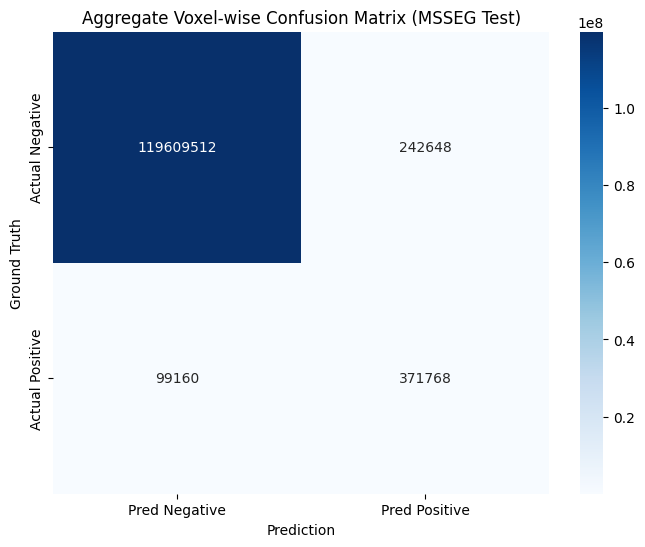

In [20]:
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from monai.metrics import get_confusion_matrix
from tqdm.auto import tqdm
import torch
import numpy as np

# Initialize counters
tp_total, fp_total, fn_total, tn_total = 0, 0, 0, 0

print("Calculating aggregate confusion matrix from cache (38 cases)...")

for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Aggregate Confusion Matrix"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    preds = cached["preds"]
    labels = cached["labels"]

    # Compute confusion matrix for this sample
    conf_m = get_confusion_matrix(y_pred=preds, y=labels)

    tp_total += conf_m[..., 0].sum().item()
    fp_total += conf_m[..., 1].sum().item()
    tn_total += conf_m[..., 2].sum().item()
    fn_total += conf_m[..., 3].sum().item()

# Construct matrix for plotting: [[TN, FP], [FN, TP]]
cm_array = np.array([[tn_total, fp_total], [fn_total, tp_total]])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_array, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=['Pred Negative', 'Pred Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title("Aggregate Voxel-wise Confusion Matrix (MSSEG Test)")
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.show()

## Test results table

In [21]:
import os
import glob
import pandas as pd
import numpy as np
from monai.metrics import DiceMetric, ConfusionMatrixMetric
import torch
from tqdm.auto import tqdm

dice_metric = DiceMetric(include_background=False, reduction="none")
conf_matrix = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall"], reduction="none")

results = []

print("Building test results table from cache...")
for cache_path in tqdm(sorted(glob.glob(os.path.join(cache_dir, "case_*.pt"))), desc="Test results table"):
    cached = torch.load(cache_path, map_location="cpu", weights_only=False)
    preds = cached["preds"]
    labels = cached["labels"]
    case_id = cached["case_id"]

    # Calculate Volumes
    gt_vol = torch.sum(labels).item()
    pred_vol = torch.sum(preds).item()

    # Calculate Metrics
    dice_metric(y_pred=preds, y=labels)
    conf_matrix(y_pred=preds, y=labels)

    dice_val = dice_metric.aggregate().item()

    # Handle Empty Ground Truth cases (NaN handling)
    if gt_vol == 0:
        if pred_vol == 0:
            dice_val = 1.0  # Perfect prediction of empty case
        else:
            dice_val = 0.0  # False positive on empty case
    elif np.isnan(dice_val):
        dice_val = 0.0

    prec_rec = conf_matrix.aggregate()
    precision_val = prec_rec[0].item() if not torch.isnan(prec_rec[0]) else (1.0 if (gt_vol == 0 and pred_vol == 0) else 0.0)
    recall_val = prec_rec[1].item() if not torch.isnan(prec_rec[1]) else (1.0 if (gt_vol == 0 and pred_vol == 0) else 0.0)

    results.append({
        "Patient ID": case_id,
        "Dice": round(float(dice_val), 4),
        "Precision": round(float(precision_val), 4),
        "Recall (Sens)": round(float(recall_val), 4),
        "Ground Truth Volume (mm3)": gt_vol,
        "Pred Volume (mm3)": pred_vol
    })

    # Reset metrics for next case
    dice_metric.reset()
    conf_matrix.reset()

# Create DataFrame
df_results = pd.DataFrame(results)
# Highlight summary
display(df_results)

Building test results table from cache...


Test results table:   0%|          | 0/38 [00:00<?, ?it/s]

,Patient ID,Dice,Precision,Recall (Sens),Ground Truth Volume (mm3),Pred Volume (mm3)
0,MSSEG_TEST_Center_01_Patient_01,0.0732,0.0384,0.7725,356.0000,7155.0000
1,MSSEG_TEST_Center_01_Patient_02,0.8049,0.7565,0.8598,24458.0000,27798.0000
2,MSSEG_TEST_Center_01_Patient_03,0.7422,0.6643,0.8407,10981.0000,13897.0000
3,MSSEG_TEST_Center_01_Patient_04,0.8305,0.7626,0.9116,34830.0000,41636.0000
4,MSSEG_TEST_Center_01_Patient_05,0.7435,0.7262,0.7616,15743.0000,16511.0000
5,MSSEG_TEST_Center_01_Patient_06,0.6703,0.7120,0.6333,30266.0000,26923.0000
6,MSSEG_TEST_Center_01_Patient_07,0.5336,0.4198,0.7323,4598.0000,8021.0000
7,MSSEG_TEST_Center_01_Patient_08,0.7724,0.7986,0.7478,21421.0000,20058.0000
8,MSSEG_TEST_Center_01_Patient_09,0.1666,0.0942,0.7202,604.0000,4618.0000
9,MSSEG_TEST_Center_01_Patient_10,0.6214,0.4929,0.8405,5166.0000,8809.0000


## centers statistics

In [22]:
import pandas as pd

# 1. Extract Center information from the Patient IDs in the results
def extract_center(patient_id):
    parts = patient_id.split('_')
    if 'Center' in parts:
        idx = parts.index('Center')
        return f"Center_{parts[idx+1]}"
    return "Unknown"

df_results['Center'] = df_results['Patient ID'].apply(extract_center)

# 2. Analyze distribution
test_centers = df_results['Center'].unique()
val_centers = set([extract_center(f['case_id']) for f in val_files])
train_centers = set([extract_center(f['case_id']) for f in train_files])

print(f"Centers in Training: {sorted(list(train_centers))}")
print(f"Centers in Validation: {sorted(list(val_centers))}")
print(f"Centers in Test: {sorted(list(test_centers))}")

# 3. Aggregate results by Center
# Fixed: Changed 'GT Volume (mm3)' to 'Ground Truth Volume (mm3)' to match df_results
center_summary = df_results.groupby('Center').agg({
    'Dice': ['mean', 'std', 'count'],
    'Precision': 'mean',
    'Recall (Sens)': 'mean',
    'Ground Truth Volume (mm3)': 'mean'
}).round(4)

print("\nPerformance Summary per Center/Scanner:")
display(center_summary)

Centers in Training: ['Center_01', 'Center_07', 'Center_08']
Centers in Validation: ['Center_01', 'Center_08']
Centers in Test: ['Center_01', 'Center_03', 'Center_07', 'Center_08']

Performance Summary per Center/Scanner:


Dice              Precision Recall (Sens)  \
            mean    std count      mean          mean   
Center                                                  
Center_01 0.5959 0.2668    10    0.5466        0.7820   
Center_03 0.5127 0.2646     8    0.4685        0.8152   
Center_07 0.5204 0.2674    10    0.4163        0.7555   
Center_08 0.5131 0.2947    10    0.4511        0.8224   

          Ground Truth Volume (mm3)  
                               mean  
Center                               
Center_01                14842.3000  
Center_03                17462.1250  
Center_07                 6241.1000  
Center_08                12039.7000

## Training Curves

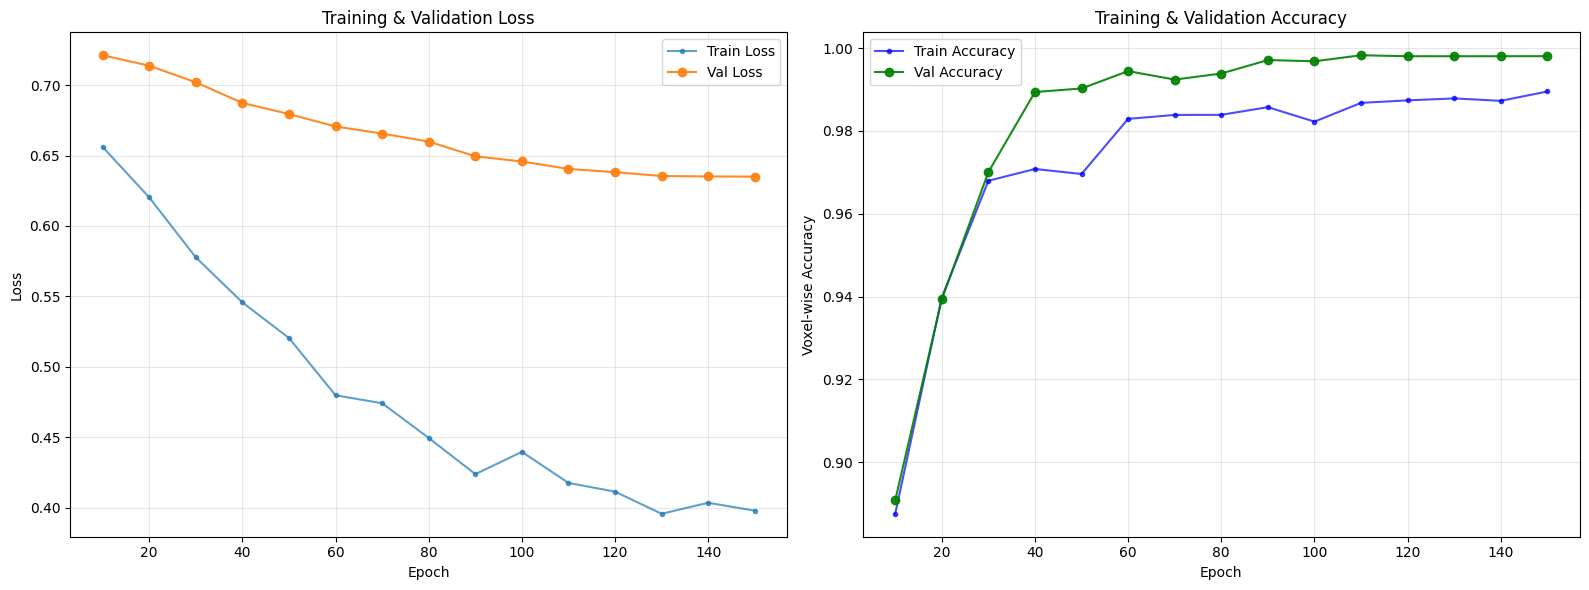

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_csv_path = "/content/training_metrics_log_flair_only.csv"

if os.path.exists(log_csv_path):
    df_log = pd.read_csv(log_csv_path)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Subplot 1: Loss
    axes[0].plot(df_log["epoch"], df_log["train_loss"], label="Train Loss", marker='.', alpha=0.7)
    axes[0].plot(df_log["epoch"], df_log["val_loss"], label="Val Loss", marker='o', alpha=0.9)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Subplot 2: Accuracy (Replacing Dice)
    axes[1].plot(df_log["epoch"], df_log["train_acc"], label="Train Accuracy", color="blue", marker='.', alpha=0.7)
    axes[1].plot(df_log["epoch"], df_log["val_acc"], label="Val Accuracy", color="green", marker='o', alpha=0.9)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Voxel-wise Accuracy")
    axes[1].set_title("Training & Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(f"Log file {log_csv_path} not found. Please ensure training has started and logged data.")